# FMRG Final Submission: Audited Local Geometry Prediction

This executed notebook is the compact submission record for predicting spatially
varying DED track width and left/right boundaries from thermal history.

**Locked protocol:** model selection and uncertainty calibration use Tracks 8, 10,
and 14 only. Track 21 is opened once for final scoring.

## Reproducibility

The full raw-data pipeline is implemented in `scripts/run_final_analysis.py`.
Recreate the tracked outputs with:

```bash
python scripts/run_final_analysis.py               --raw-dir /path/to/extracted/zenodo/data               --output-dir results/final_submission
```

The official Zenodo archives were verified against the record's MD5 checksums before
analysis. This notebook reads the tracked, locked results so it executes without
redistributing the large raw archives.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "results/final_submission/metrics.json").exists():
    ROOT = ROOT.parent

RESULTS = ROOT / "results/final_submission"
metrics = json.loads((RESULTS / "metrics.json").read_text())
metrics["data_split"]

{'development_tracks': [8, 10, 14],
 'selection_and_calibration': 'leave-one-track-out cross-validation',
 'untouched_test_track': 21,
 'steady_state_x_mm': [24.0, 96.0],
 'samples': {'development': 1066, 'test': 336}}

## Audit corrections

The prior report/deck asserted a 21.18 micrometer MAE, positive R-squared, a Random
Forest result, and dominant SEM importance. Those claims were not produced by the
supplied notebook. This submission replaces them with a reproduced notebook baseline
and an audited pipeline evaluated on the same untouched Track 21 samples.

In [2]:
baseline = metrics["baseline"]
corrected = metrics["corrected"]

comparison = pd.DataFrame(
    [
        {
            "model": "Notebook Gradient Boosting",
            "development_CV_MAE_mm": baseline["development_oof_metrics"]["mae_mm"],
            "Track21_MAE_mm": baseline["test_metrics"]["mae_mm"],
            "Track21_RMSE_mm": baseline["test_metrics"]["rmse_mm"],
            "Track21_R2": baseline["test_metrics"]["r2"],
            "interval_coverage": baseline["test_interval_metrics"]["coverage"],
            "interval_width_mm": baseline["test_interval_metrics"]["mean_width_mm"],
        },
        {
            "model": "Audited Ridge alpha=10",
            "development_CV_MAE_mm": corrected["development_oof_metrics"]["mae_mm"],
            "Track21_MAE_mm": corrected["test_metrics"]["mae_mm"],
            "Track21_RMSE_mm": corrected["test_metrics"]["rmse_mm"],
            "Track21_R2": corrected["test_metrics"]["r2"],
            "interval_coverage": corrected["test_interval_metrics"]["coverage"],
            "interval_width_mm": corrected["test_interval_metrics"]["mean_width_mm"],
        },
    ]
)
comparison.round(4)

,model,development_CV_MAE_mm,Track21_MAE_mm,Track21_RMSE_mm,Track21_R2,interval_coverage,interval_width_mm
0,Notebook Gradient Boosting,0.1369,0.1589,0.1873,-0.9884,0.8155,0.5084
1,Audited Ridge alpha=10,0.0876,0.1394,0.1668,-0.5767,0.7649,0.4166


In [3]:
improvement = metrics["held_out_mae_improvement_percent"]
print(f"Held-out MAE improvement: {improvement:.1f}%")
print(
    "Interpretation: the audited model is better on the untouched condition, "
    "but negative R^2 and interval under-coverage prevent a deployment claim."
)

Held-out MAE improvement: 12.3%
Interpretation: the audited model is better on the untouched condition, but negative R^2 and interval under-coverage prevent a deployment claim.


## Local geometry target

Each profilometer cross-section is robustly detrended. Connected 30%-of-peak crossings
around the central bead maximum define the local left and right boundaries; width is
their difference. Invalid acquisition gaps remain excluded. Thermal frames map to the
physical x-axis using 10 mm/s at 50 fps, or 0.2 mm per frame.

In [4]:
boundary = metrics["boundary_metrics"]
pd.DataFrame(
    [
        {"signal": "left boundary", **boundary["left"]},
        {"signal": "right boundary", **boundary["right"]},
        {
            "signal": "mean boundary MAE",
            "mae_mm": boundary["mean_boundary_mae_mm"],
            "rmse_mm": float("nan"),
            "r2": float("nan"),
        },
    ]
).round(4)

,signal,mae_mm,rmse_mm,r2
0,left boundary,0.1512,0.1923,-0.1547
1,right boundary,0.1970,0.2508,-0.1241
2,mean boundary MAE,0.1741,NaN,NaN


## Model selection and SEM ablation

Candidate models and feature families are compared by leave-one-track-out development
cross-validation. Masked SEM is tested as a substrate-only feature family, not assumed
beneficial.

In [5]:
candidates = corrected["candidate_cv_mae_mm"]
(
    pd.Series(candidates, name="grouped_CV_MAE_mm")
    .sort_values()
    .rename_axis("candidate")
    .to_frame()
    .round(4)
)

,grouped_CV_MAE_mm
candidate,
thermal:ridge_10,0.0876
thermal:ridge_1,0.0876
thermal_plus_masked_sem:ridge_10,0.1135
thermal_plus_masked_sem:ridge_1,0.1210
thermal_plus_masked_sem:hist_gradient_boosting,0.1404
thermal_plus_masked_sem:extra_trees,0.1419
thermal:extra_trees,0.1422
thermal:hist_gradient_boosting,0.1423


In [6]:
print("Selected model:", corrected["model_name"])
print("Selected feature family:", corrected["feature_set"])
print("Masked SEM selected:", metrics["masked_sem_selected"])

Selected model: ridge_10
Selected feature family: thermal
Masked SEM selected: False


## Held-out spatial predictions and uncertainty

The interval half-width is calibrated from grouped development residuals only. Observed
Track 21 coverage is reported directly, even though it falls below the nominal 90%.

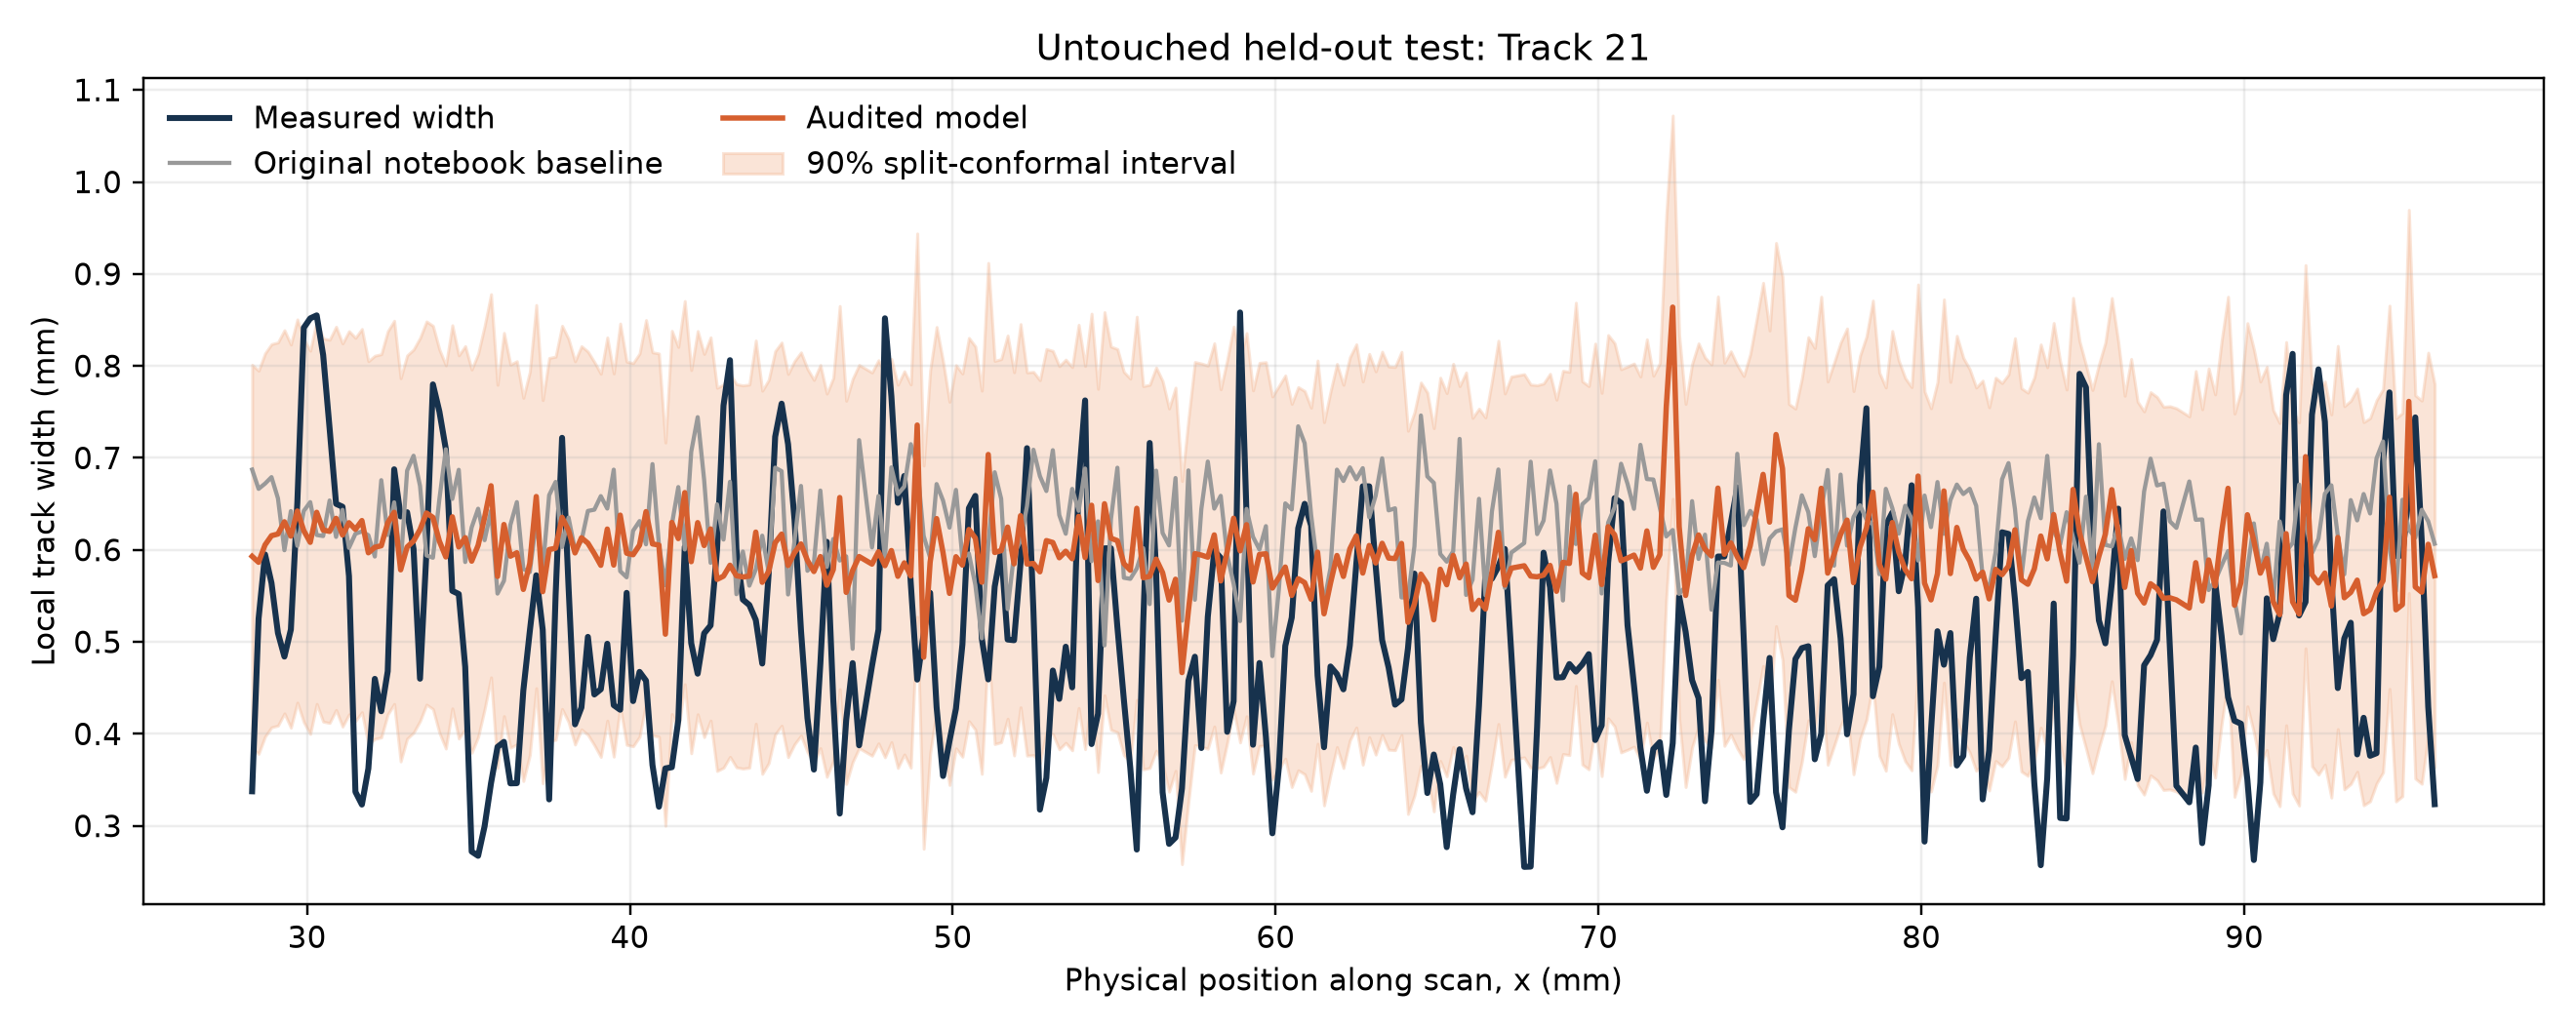

In [7]:
display(
    Image(
        filename=str(RESULTS / "figures/track21_held_out_comparison.png"),
        width=1050,
    )
)

## Interpretable thermal links

Validation permutation importance identifies hot-region mean temperature and thermal
mass as the strongest predictive associations. These features reflect melt-pool thermal
state and short process memory; importance is not a causal substrate/process separation.

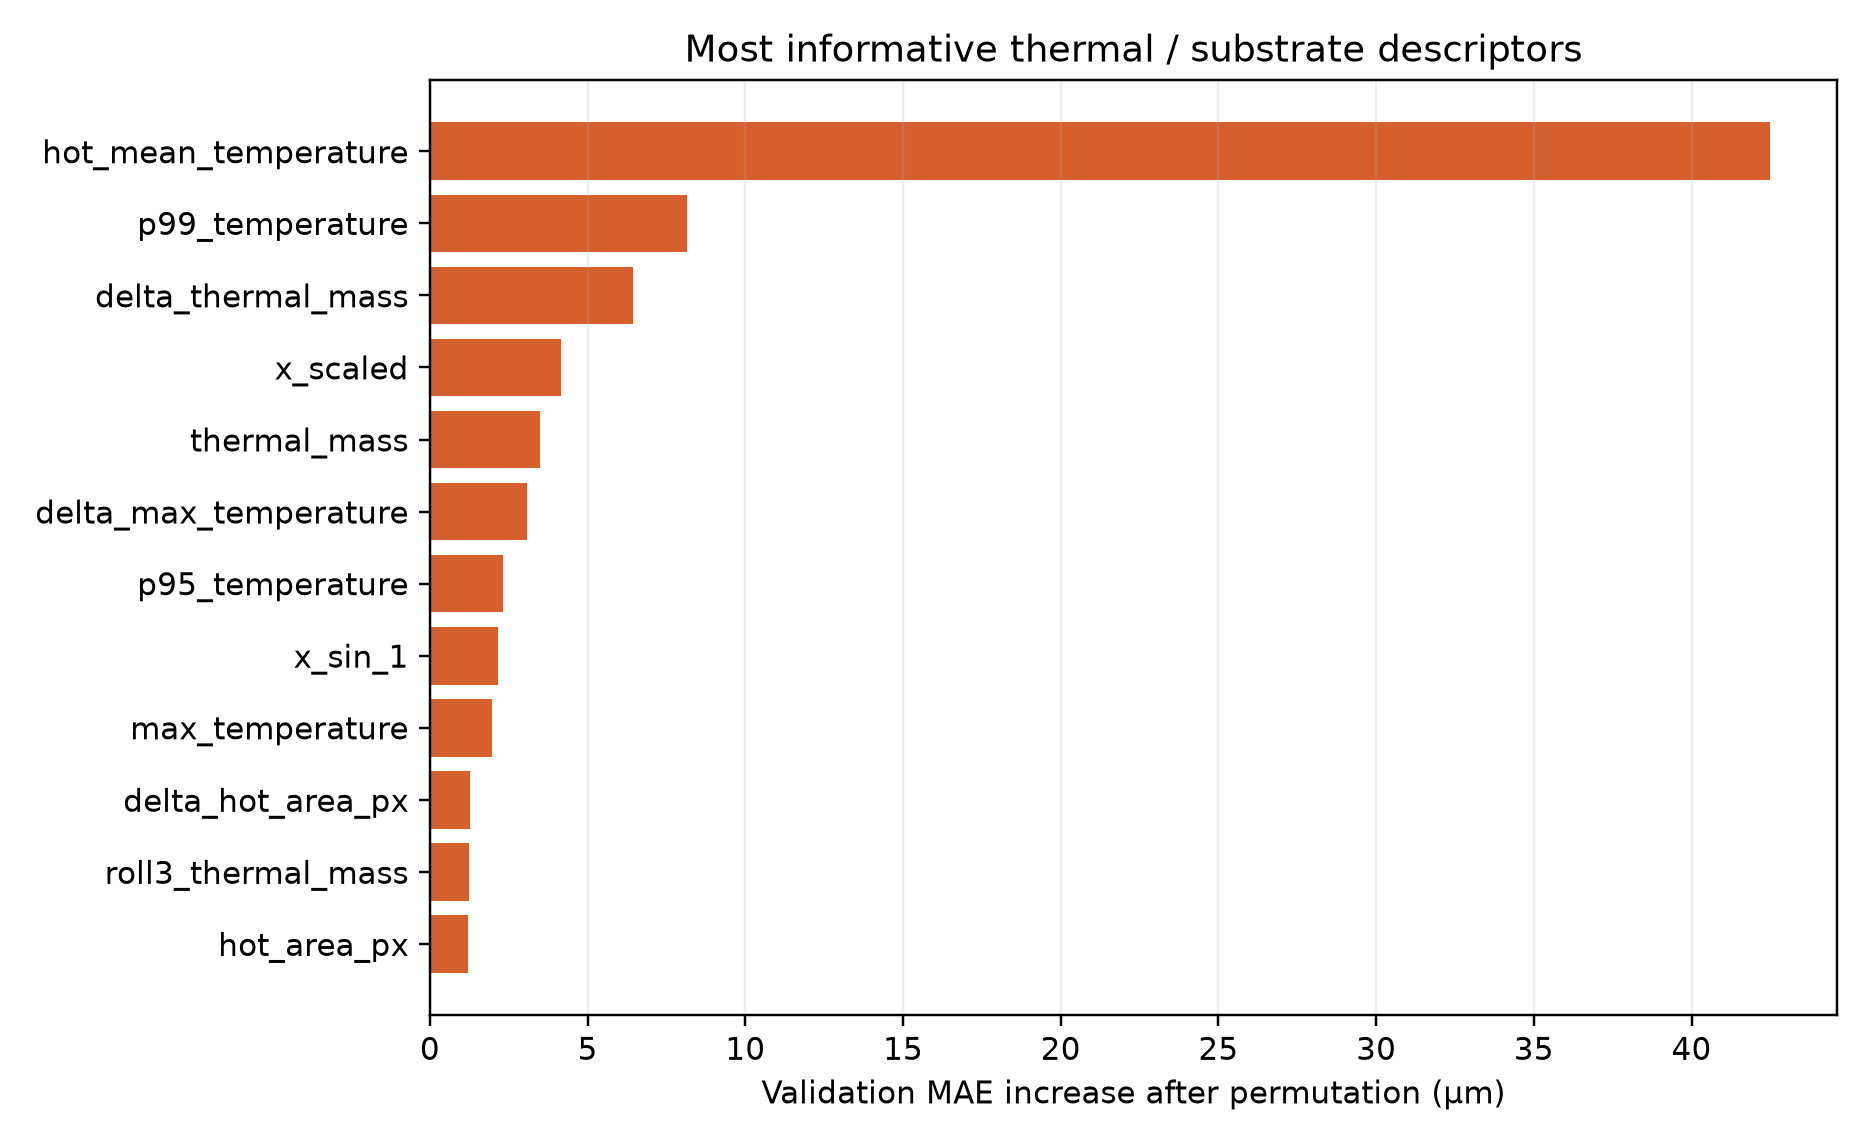

In [8]:
display(
    Image(
        filename=str(RESULTS / "figures/feature_importance.png"),
        width=900,
    )
)

## Honest conclusion

- Track 21 local-width MAE improves from **0.159 mm to 0.139 mm** (12.3%).
- Development grouped-CV MAE improves from **0.137 mm to 0.088 mm**.
- Held-out R-squared remains **-0.58**.
- Nominal 90% intervals cover **76.5%** of held-out samples.
- Mean left/right boundary MAE is **0.174 mm**.
- Masked SEM worsens grouped CV and is not selected.

The contribution is a reproducible, leakage-controlled benchmark and spatial pipeline,
not a closed-loop-ready controller.

## Generative AI disclosure

OpenAI Codex assisted with code review, test generation, debugging, and artifact
layout. Reported metrics were produced by the tracked analysis code and verified
against saved predictions; AI did not supply or alter experimental measurements.

## Sources

- Official dataset: https://doi.org/10.5281/zenodo.21285367
- Dataset paper: https://arxiv.org/abs/2607.07965
- Locked metrics: `results/final_submission/metrics.json`